# Titanic - Machine Learning from Disaster

| Variable  | Definition                                   | Key                                      |
|-----------|----------------------------------------------|------------------------------------------|
| survival  | Survival                                     | 0 = No, 1 = Yes                          |
| pclass    | Ticket class                                 | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex       | Sex                                          |                                          |
| age       | Age in years                                 |                                          |
| sibsp     | # of siblings / spouses aboard the Titanic   |                                          |
| parch     | # of parents / children aboard the Titanic   |                                          |
| ticket    | Ticket number                                |                                          |
| fare      | Passenger fare                               |                                          |
| cabin     | Cabin number                                 |                                          |
| embarked  | Port of Embarkation                          | C = Cherbourg, Q = Queenstown, S = Southampton |

---
## Import Libraries

In [28]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

---
## Read Files

In [13]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

---
## Explore the data

In [7]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Age ==> Min age is a baby and the max age is 80 years old

Pclass ==> common class was the second class

In [ ]:
# A summary of the categorical (text) columns
df_train.describe(include='O').T

C:\Users\fifif\AppData\Local\Temp\ipykernel_30416\2573242512.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_train.describe(include='O').T


,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


Note: Ticket has 681 unique values so does this mean that there are double in the tickes? 

Cabin can make sense because multiple people can be assigned to the same cabin


In [10]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [11]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are missing values in age , cabin and embarked

Cabin number has the higest amount of missing values

This can be interesting if we want to remove certain columns or change them 

In [12]:
print(len(df_train))

891


---
###  Classes Likely to survive

- Ticket class : this will impact your likelyhood of survival. If you have a higher classs you might be closer to the exit
- Sex: This will def have an impact as Women and children and elderly are known to have a priority when it comes to disasters
- Age: Same things age does impact survivalhood children and elderly will be prioritised 

In [23]:
#Look if women actualy had a higher survival rate than men
df_train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [24]:
print("Women had a higher percentage of survival with 74% whereas men its as low as 18%")

Women had a higher percentage of survival with 74% whereas men its as low as 18%


In [26]:
#Look if class actually had an impact on survival
df_train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Also confirms the hypothesis that the higher classes did have a higher likelyhood of surviving , the third class survival was to be at 24%

In [52]:
bins = int((df_train['Age'].max() - df_train['Age'].min()) / 5)
print(round(bins, 3))

15


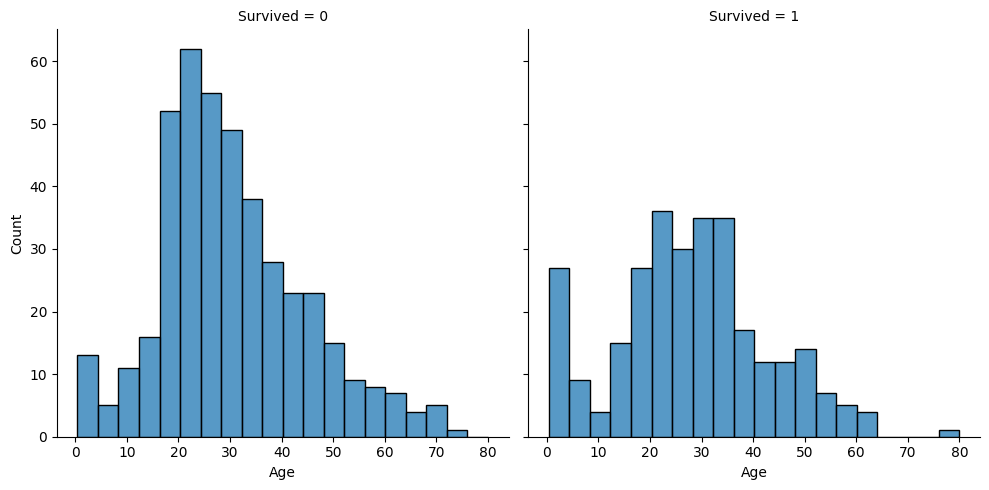

In [ ]:
sns.displot(data=df_train, x='Age', col='Survived', bins=16)

Note: that people between 20 and 30 had the highest rates of not surviving the disaster

---

Look at the people who survived

In [18]:
df_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [20]:
survival_rate = df_train['Survived'].value_counts(normalize=True)
print((survival_rate * 100), "%")


Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64 %


Look at the balance between those who have survived and those who didn't
We see that 61% did not survive whereas 38% did survive the disaster

Within those people look at the title they have as this also impact

Look if the groupsize actually matter in surving? 

In [62]:
df_train['Family-size'] = df_train['SibSp'] + df_train['Parch'] + 1


In [65]:
df_train.groupby('Family-size')['Survived'].mean()*100

Family-size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

what we can see is that smaller/ midsize family have a higher change of survival so with a max of 4 members anything above that had a lower chance of surviving

In [67]:
df_train.groupby('SibSp')['Survived'].mean()*100

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

In [69]:
df_train.groupby('Ticket')['Survived'].mean()*100

Ticket
110152         100.000000
110413          66.666667
110465           0.000000
110564         100.000000
110813         100.000000
                  ...    
W./C. 6608       0.000000
W./C. 6609       0.000000
W.E.P. 5734      0.000000
W/C 14208        0.000000
WE/P 5735       50.000000
Name: Survived, Length: 681, dtype: float64